In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
df = pd.read_csv("../../../cleaned/student_records_clean.csv")
df.head()

,record_id,student_id,student_name,gender,age,class,location,subject,attendance_percent,study_hours_per_week,assignment_marks,test_marks,exam_marks,final_score,final_grade,academic_term,academic_year,term_number,period
0,1,1,Thomas Brown,Male,13,Form 1,Kisumu,History,80.6,4.0,89.0,88.5,100.0,94.4,A,Term 1,2023,1,2023-Term 1
1,2,1,Thomas Brown,Male,13,Form 1,Kisumu,Mathematics,89.7,2.3,80.1,79.1,84.3,81.9,A,Term 1,2023,1,2023-Term 1
2,3,1,Thomas Brown,Male,13,Form 1,Kisumu,Biology,62.9,0.4,59.3,66.5,57.1,60.4,C,Term 1,2023,1,2023-Term 1
3,4,1,Thomas Brown,Male,13,Form 1,Kisumu,English,67.9,5.2,79.9,69.6,75.2,74.5,B,Term 1,2023,1,2023-Term 1
4,5,1,Thomas Brown,Male,13,Form 1,Kisumu,Physics,83.1,1.3,74.2,75.1,72.4,73.6,B,Term 1,2023,1,2023-Term 1


In [3]:
#Overall summary stats
print("Average final score:", round(df["final_score"].mean(), 2))
df[["attendance_percent", "study_hours_per_week", "final_score"]].describe()

Average final score: 71.92


,attendance_percent,study_hours_per_week,final_score
count,16165.000000,16165.000000,16165.000000
mean,81.870702,3.021039,71.922815
std,9.699357,1.476643,14.177538
min,40.400000,0.000000,10.000000
25%,75.300000,2.000000,62.400000
50%,82.100000,3.000000,72.100000
75%,88.800000,4.000000,82.200000
max,100.000000,8.500000,100.000000


In [5]:
import os
print(os.getcwd())

c:\Users\Nicole Kasiva\Documents\Python-data-analysis\student-performance-analysis\data\raw\scripts\notebooks


In [6]:
import os 
print(os.path.exists("../outputs/figures"))

False


C:\Users\Nicole Kasiva\AppData\Local\Temp\ipykernel_3788\2169258760.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=subject_avg.values, y=subject_avg.index, palette="viridis")


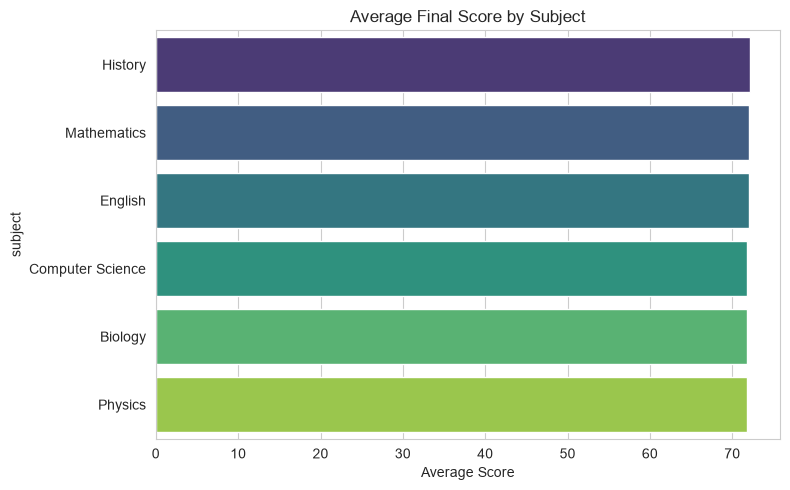

In [7]:
#Performance by subject
import os 

os.makedirs("../outputs/figures", exist_ok=True)


plt.figure(figsize=(8,5))
sns.barplot(x=subject_avg.values, y=subject_avg.index, palette="viridis")
plt.title("Average Final Score by Subject")
plt.xlabel("Average Score")
plt.tight_layout()
plt.savefig("../outputs/figures/avg_score_by_subject.png")
plt.show()

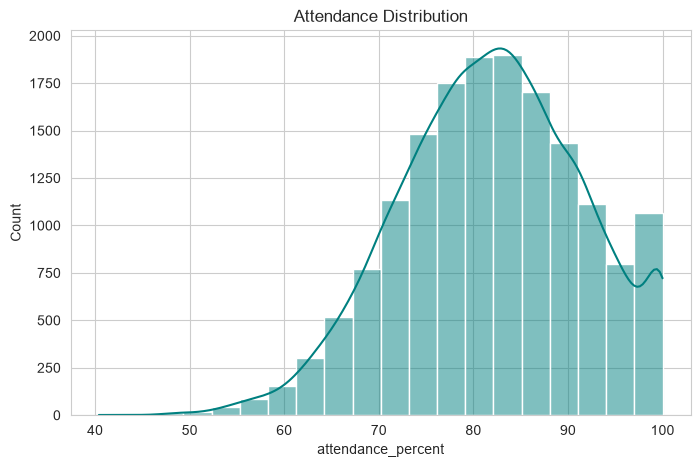

In [8]:
#attendance distribution
plt.figure(figsize=(8,5))
sns.histplot(df["attendance_percent"], bins=20, kde=True, color="teal")
plt.title("Attendance Distribution")
plt.savefig("../outputs/figures/attendance_distribution.png")
plt.show()

attendance_band
<70%      67.858420
70–85%    71.199816
≥85%      74.083573
Name: final_score, dtype: float64
Students with attendance ≥85% score 9.2% higher on average than students below 70% attendance.


C:\Users\Nicole Kasiva\AppData\Local\Temp\ipykernel_3788\3391730848.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=band_avg.index, y=band_avg.values, palette="crest")


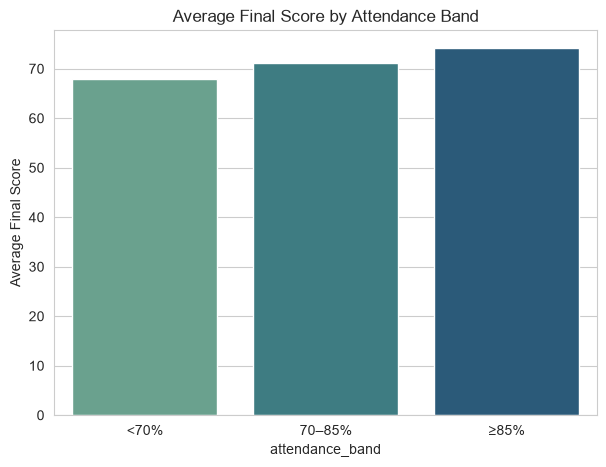

In [10]:
# attendance vs performance

def attendance_band(pct):
    if pct >= 85: return "≥85%"
    elif pct >= 70: return "70–85%"
    else: return "<70%"

df["attendance_band"] = df["attendance_percent"].apply(attendance_band)
band_avg = df.groupby("attendance_band")["final_score"].mean().reindex(["<70%", "70–85%", "≥85%"])
print(band_avg)

# Generate the exact style of insight statement from your brief
high = band_avg["≥85%"]
low = band_avg["<70%"]
pct_diff = round((high - low) / low * 100, 1)
print(f"Students with attendance ≥85% score {pct_diff}% higher on average "
      f"than students below 70% attendance.")

plt.figure(figsize=(7,5))
sns.barplot(x=band_avg.index, y=band_avg.values, palette="crest")
plt.title("Average Final Score by Attendance Band")
plt.ylabel("Average Final Score")
plt.savefig("../outputs/figures/score_by_attendance_band.png")
plt.show()

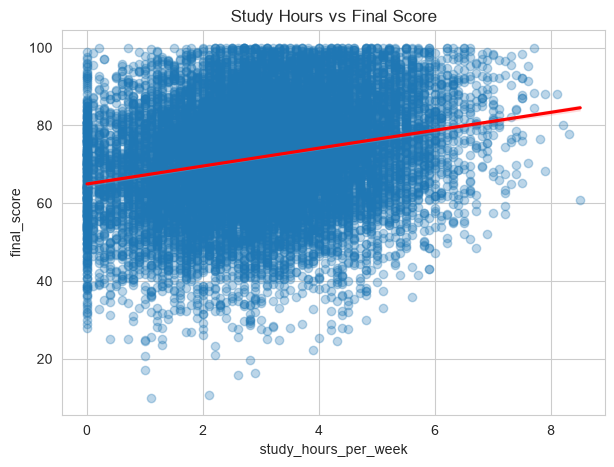

Correlation (study hours, final score): 0.24


In [4]:
#study hours vs performance
plt.figure(figsize=(7,5))
sns.regplot(data=df, x="study_hours_per_week", y="final_score",
            scatter_kws={"alpha":0.3}, line_kws={"color":"red"})
plt.title("Study Hours vs Final Score")
plt.savefig("../outputs/figures/study_hours_vs_score.png")
plt.show()

corr = df["study_hours_per_week"].corr(df["final_score"])
print("Correlation (study hours, final score):", round(corr, 3))

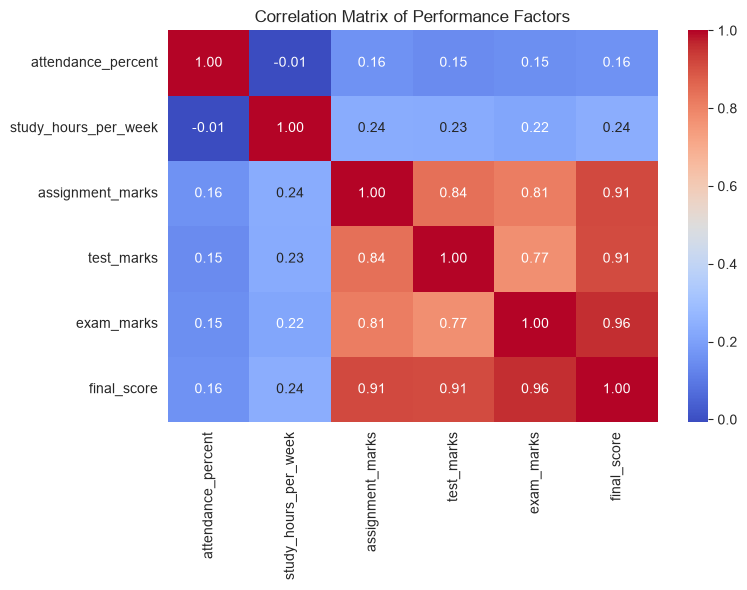

In [6]:
#Correlation heat map
numeric_cols = ["attendance_percent", "study_hours_per_week", "assignment_marks",
                 "test_marks", "exam_marks", "final_score"]
corr_matrix = np.corrcoef(df[numeric_cols].T)  # NumPy used explicitly here
corr_df = pd.DataFrame(corr_matrix, index=numeric_cols, columns=numeric_cols)

plt.figure(figsize=(8,6))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Performance Factors")
plt.tight_layout()
plt.savefig("../outputs/figures/correlation_heatmap.png")
plt.show()